# Task 1.1 — Sentiment Analysis with a Feedforward ANN

We classify Amazon product reviews as **positive (1)** or **negative (0)** using a
TF-IDF bag-of-words representation fed into a simple feedforward neural network.

**Pipeline overview**
```
Raw text  →  Preprocessing  →  TF-IDF vectors  →  ANN  →  {0, 1}
```

## Setup & Imports

In [4]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from data_loading_code import preprocess_pandas
from utils import device_check, fit, evaluate

# Suppress NumPy 2.4 VisibleDeprecationWarning triggered inside torchvision
warnings.filterwarnings("ignore", category=np.exceptions.VisibleDeprecationWarning)

device = device_check()

PyTorch: 2.11.0+cpu | Python: 3.13.7 | OS: Windows 11
CUDA available: False
Using cpu


## Notebook parameters

In [8]:
LOG_WANDB   = True  # Set False to disable wandb logging
NUM_WORKERS = 8
PIN_MEMORY  = True
SEED = 1

# Make results reproducible
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Load & Preprocess Data

In [9]:
raw = pd.read_csv('../data/amazon_cells_labelled.txt', delimiter='\t', header=None,
                  names=['Sentence', 'Class'])
print(f'Loaded {len(raw)} reviews')
print(raw['Class'].value_counts().rename({0: 'negative', 1: 'positive'}))
raw.head()

Loaded 1000 reviews
Class
negative    500
positive    500
Name: count, dtype: int64


,Sentence,Class
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [10]:
data = preprocess_pandas(raw)
data.head()

,Sentence,Class
0,way plug us unless go converter,0
1,good case excellent value,1
2,great jawbone,1
3,tied charger conversations lasting minutesmajo...,0
4,mic great,1


## Train / Validation / Test Split

We carve out a held-out **test set** first (10 %), then further split the remainder
into **train** (81 %) and **validation** (9 %) sets. To ensure stratification, we use `train_test_split` from `sklearn`.

In [11]:
sentences = data['Sentence'].values.astype('U') # as numpy Unicode string
labels    = data['Class'].values.astype('int32')

# First, split off the test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    sentences, labels, test_size=0.10, random_state=SEED, shuffle=True, stratify=labels
)

# Then split train/val from the remaining data
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.10, random_state=SEED, shuffle=True, stratify=y_trainval
)

print(f'Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

Train: 810  |  Val: 90  |  Test: 100


## TF-IDF Vectorization

TF-IDF stands for Term Frequency–Inverse Document Frequency. The core idea is to represent each review as a fixed-length numeric vector where each position corresponds to a word (or word pair), and the value captures how distinctive that word is for that particular review.
The two components are:

1. TF (Term Frequency) — how often a word appears in this review. A review that says "great" three times scores higher on "great" than one that says it once.
2. IDF (Inverse Document Frequency) — a penalty for words that appear in most reviews. A word like "phone" appears in almost every review, so it tells you very little about sentiment and gets down-weighted. A word like "worthless" appears rarely and is much more informative.

Multiply them together and you get a score that's high for words that are frequent in this review but rare across the dataset — exactly the words that carry signal.

The vectorizer is **fit only on the training set** to avoid data leakage, then used
to transform all three splits.

In [12]:
vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),   # unigrams + bigrams: consider single words like "good" AND pairs like "not good"
    max_features=50_000,  # cap vocabulary size
    max_df=0.5,           # drop words appearing in >50% of reviews
    use_idf=True,         # apply the IDF weighting
    norm='l2',            # normalize each row vector to unit length
)

X_train_tfidf = torch.from_numpy(np.array(vectorizer.fit_transform(X_train).todense())).float()
X_val_tfidf   = torch.from_numpy(np.array(vectorizer.transform(X_val).todense())).float()
X_test_tfidf  = torch.from_numpy(np.array(vectorizer.transform(X_test).todense())).float()

y_train_t = torch.from_numpy(y_train).long()
y_val_t   = torch.from_numpy(y_val).long()
y_test_t  = torch.from_numpy(y_test).long()

INPUT_DIM = X_train_tfidf.shape[1]
print(f'Vocabulary size (TF-IDF features): {INPUT_DIM}')

Vocabulary size (TF-IDF features): 4671


## DataLoaders

In [13]:
BATCH_SIZE = 32

train_loader = DataLoader(TensorDataset(X_train_tfidf, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_tfidf,   y_val_t),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_tfidf,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

## Model Definition

A three-layer feedforward network with **BatchNorm** and **Dropout** for regularization.

```
Input (vocab_size)  →  FC(256) → BN → ReLU → Dropout
                    →  FC(64)  → BN → ReLU → Dropout
                    →  FC(2)   →  logits
```

In [41]:
class SentimentANN(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int], dropout: float = 0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 2))  # 2 output classes
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [49]:
HIDDEN_DIMS = [256, 64]
DROPOUT = 0.1

model = SentimentANN(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

SentimentANN(
  (net): Sequential(
    (0): Linear(in_features=4671, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=64, out_features=2, bias=True)
  )
)

Trainable parameters: 1,213,250


## Training

In [50]:
NUM_EPOCHS    = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

wandb_kwargs = {
    'project': 'lab1-sentiment',
    'name':    'ann-tfidf-baseline',
    'config':  {
        'hidden_dims': HIDDEN_DIMS,
        'dropout':     DROPOUT,
        'lr':          LEARNING_RATE,
        'batch_size':  BATCH_SIZE,
        'epochs':      NUM_EPOCHS,
        'optimizer':   'Adam',
    },
}

# Set log=True if you have wandb set up, otherwise leave as False
history = fit(
    model, optimizer, criterion,
    train_loader, val_loader,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs=wandb_kwargs,
    log=False,
)

Epoch  1/50 | train loss 0.7025, train acc 52.72% | val loss 0.6923, val acc 52.22%
Epoch  2/50 | train loss 0.4554, train acc 87.65% | val loss 0.6801, val acc 66.67%
Epoch  3/50 | train loss 0.3178, train acc 97.41% | val loss 0.6162, val acc 68.89%
Epoch  4/50 | train loss 0.2432, train acc 98.77% | val loss 0.5503, val acc 70.00%
Epoch  5/50 | train loss 0.1888, train acc 99.63% | val loss 0.5297, val acc 71.11%
Epoch  6/50 | train loss 0.1523, train acc 99.51% | val loss 0.5327, val acc 70.00%
Epoch  7/50 | train loss 0.1234, train acc 99.63% | val loss 0.5222, val acc 72.22%
Epoch  8/50 | train loss 0.1051, train acc 99.88% | val loss 0.5225, val acc 71.11%
Epoch  9/50 | train loss 0.0890, train acc 99.88% | val loss 0.5225, val acc 70.00%
Epoch 10/50 | train loss 0.0819, train acc 99.88% | val loss 0.5199, val acc 71.11%
Epoch 11/50 | train loss 0.0685, train acc 99.88% | val loss 0.5268, val acc 70.00%
Epoch 12/50 | train loss 0.0649, train acc 99.75% | val loss 0.5313, val acc

## Learning Curves

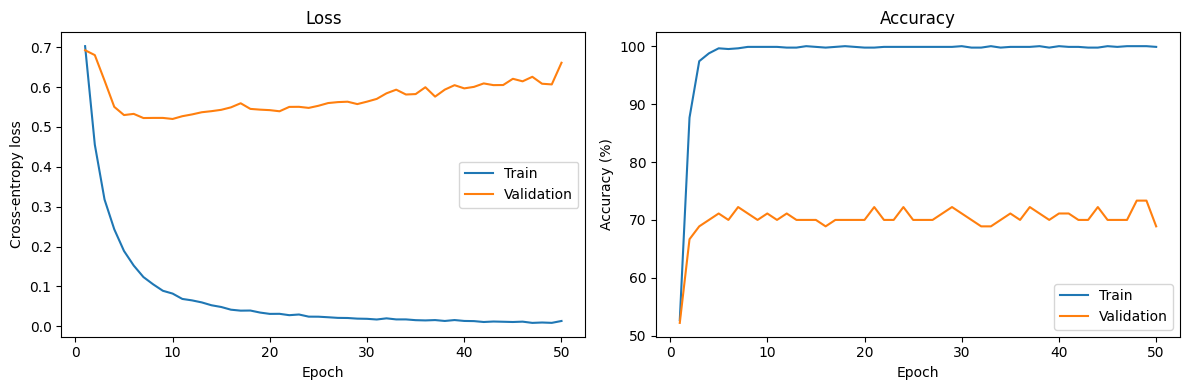

In [51]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['train_loss'], label='Train')
ax1.plot(epochs, history['val_loss'],   label='Validation')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-entropy loss')
ax1.legend()

ax2.plot(epochs, history['train_acc'], label='Train')
ax2.plot(epochs, history['val_acc'],   label='Validation')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.show()

## Evaluation on the Test Set

In [52]:
evaluate(model, test_loader, criterion, label='ANN TF-IDF baseline')

[ANN TF-IDF baseline] Test loss: 0.4824 | Test acc: 76.00%


(0.482430739402771, 76.0)

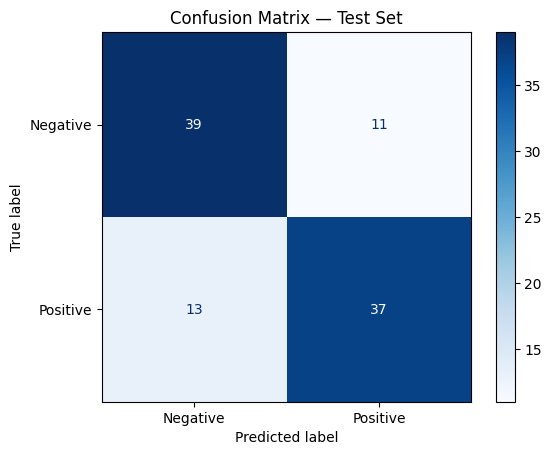

In [54]:
# Collect all predictions for detailed metrics
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        preds  = model(inputs).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive']).plot(cmap='Blues')
plt.title('Confusion Matrix — Test Set')
plt.show()

## Quick Inference Demo

In [56]:
def predict(texts: list[str]) -> list[str]:
    """Return 'Positive' / 'Negative' predictions for a list of raw review strings."""
    vec   = torch.from_numpy(np.array(vectorizer.transform(texts).todense())).float().to(device)
    model.eval()
    with torch.no_grad():
        preds = model(vec).argmax(dim=1).cpu().numpy()
    return ['Positive' if p == 1 else 'Negative' for p in preds]


examples = [
    "Absolutely love this product, battery lasts all day!",
    "Terrible product, broke after two days. Complete waste of money.",
    "It's okay, nothing special but gets the job done.",
]

for text, label in zip(examples, predict(examples)):
    print(f'[{label}]  {text}')

[Positive]  Absolutely love this product, battery lasts all day!
[Negative]  Terrible product, broke after two days. Complete waste of money.
[Positive]  It's okay, nothing special but gets the job done.
